In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

data_x = [(4.9, 3.3), (5.6, 4.5), (6.4, 4.3), (6.7, 5.7), (6.3, 5.0), (5.2, 3.9), (5.5, 3.7), (5.6, 3.6), (5.5, 3.8), (6.1, 4.7), (7.4, 6.1), (6.0, 5.1), (5.5, 4.4), (5.9, 5.1), (6.5, 5.8), (6.5, 4.6), (6.7, 4.4), (6.3, 5.6), (5.9, 4.8), (6.0, 4.5), (5.6, 4.1), (5.6, 4.9), (4.9, 4.5), (6.2, 4.5), (6.1, 4.7), (6.1, 4.9), (6.2, 5.4), (5.7, 4.2), (6.1, 5.6), (5.8, 4.0), (6.6, 4.6), (5.6, 4.2), (7.2, 6.1), (7.7, 6.7), (5.6, 3.9), (7.7, 6.9), (6.0, 4.0), (6.1, 4.0), (7.6, 6.6), (5.1, 3.0), (6.3, 6.0), (6.7, 5.7), (6.8, 5.9), (6.4, 5.5), (7.0, 4.7), (5.8, 5.1), (5.8, 5.1), (6.4, 5.3), (6.3, 4.9), (6.4, 5.3), (5.7, 3.5), (7.2, 5.8), (6.4, 5.6), (5.7, 4.5), (6.0, 4.5), (7.7, 6.1), (6.2, 4.3), (7.1, 5.9), (7.3, 6.3), (5.0, 3.3), (6.3, 5.1), (5.8, 3.9), (6.4, 4.5), (6.3, 5.6), (6.8, 5.5), (6.9, 5.4), (5.5, 4.0), (5.7, 4.1), (6.5, 5.5), (6.3, 4.7), (5.0, 3.5), (6.7, 5.8), (6.9, 4.9), (7.7, 6.7), (5.8, 4.1), (6.4, 5.6), (6.7, 5.2), (6.7, 4.7), (5.4, 4.5), (6.8, 4.8), (5.7, 4.2), (5.5, 4.0), (6.3, 4.9), (6.5, 5.2), (5.8, 5.1), (6.0, 4.8), (6.2, 4.8), (6.5, 5.1), (7.9, 6.4), (6.7, 5.0), (6.7, 5.6), (6.0, 5.0), (6.1, 4.6), (5.7, 5.0), (7.2, 6.0), (6.3, 4.4), (5.9, 4.2), (6.9, 5.1), (6.6, 4.4), (6.9, 5.7)]
data_y = [-1, -1, -1, 1, 1, -1, -1, -1, -1, -1, 1, -1, -1, 1, 1, -1, -1, 1, -1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1, 1, -1, -1, 1, -1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, -1, 1, 1, -1, -1, 1, -1, 1, 1, -1, 1, -1, -1, 1, 1, 1, -1, -1, 1, -1, -1, 1, -1, 1, -1, 1, 1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, -1, 1, 1, -1, 1, 1, -1, -1, 1, -1, 1]

data_x = np.array(data_x)
data_y = np.array(data_y)

x_train, x_test, y_train, y_test = train_test_split(data_x, data_y, random_state=123,test_size=0.3, shuffle=True)

# здесь продолжайте программу
predict = []
for coord in x_test:
    s = [abs(coord[0] - x[0]) + abs(coord[1] - x[1]) for x in x_train]
    indexes = np.argsort(s)[0:5]
    y = [y_train[i] for i in indexes]
    predict.append(max(y, key=y.count))
Q = sum(np.array(predict) != y_test)

"""
k = 5
# разность массивов
diff = x_test[:, np.newaxis, :] - x_train[np.newaxis, :, :]
# получение индексов k-соседей
idxs = np.abs(diff).sum(axis=2).argsort()[:, :k]
predict = np.sign(y_train[idxs].sum(axis=1))
Q = (predict != y_test).sum()
"""

In [17]:
dist = []
for x in x_test:
    row = []
    for y in x_train:
        row.append(np.sqrt(((x - y)**2).sum()))
    dist.append(row)

In [51]:
x_test_ = x_test[:, None, :]
x_train_ = x_train[None, :, :]
diff = x_test_ - x_train_
dist = np.sqrt((diff**2).sum(axis=2))
dist

array([[1.1045361 , 2.16333077, 3.64005494, ..., 1.96977156, 1.        ,
        0.2       ],
       [1.52315462, 2.70185122, 4.18688428, ..., 2.46981781, 1.55563492,
        0.70710678],
       [0.7       , 0.80622577, 2.28035085, ..., 0.7       , 0.36055513,
        1.20415946],
       ...,
       [0.53851648, 1.08166538, 2.56124969, ..., 0.92195445, 0.1       ,
        0.92195445],
       [0.41231056, 1.48660687, 2.97321375, ..., 1.25299641, 0.41231056,
        0.53851648],
       [1.36014705, 0.1       , 1.41421356, ..., 0.41231056, 1.25299641,
        2.0808652 ]])

In [53]:
import numpy as np
import time

# -------------------------
# 1. Генерация данных
# -------------------------
np.random.seed(42)

n_test = 500
n_train = 2000
d = 10

x_test = np.random.randn(n_test, d)
x_train = np.random.randn(n_train, d)

# -------------------------
# 2. ЦИКЛОВАЯ РЕАЛИЗАЦИЯ
# -------------------------
start = time.time()

dist_loop = []
for x in x_test:
    row = []
    for y in x_train:
        row.append(np.sqrt(((x - y) ** 2).sum()))
    dist_loop.append(row)

dist_loop = np.array(dist_loop)

t_loop = time.time() - start

# -------------------------
# 3. NUMPY ВЕКТОРИЗАЦИЯ
# -------------------------
start = time.time()

x_test_ = x_test[:, None, :]
x_train_ = x_train[None, :, :]

dist_vec = np.sqrt(((x_test_ - x_train_) ** 2).sum(axis=2))

t_vec = time.time() - start

# -------------------------
# 4. РЕЗУЛЬТАТЫ
# -------------------------
print("Loop time:", t_loop)
print("Vectorized time:", t_vec)
print("Speedup:", t_loop / t_vec)

# проверка корректности
print("Max diff:", np.abs(dist_loop - dist_vec).max())

Loop time: 2.997624397277832
Vectorized time: 0.05779433250427246
Speedup: 51.86709954745531
Max diff: 0.0


In [70]:
import numpy as np
from sklearn.model_selection import train_test_split


np.random.seed(0)
n_feature = 5 # количество признаков

# исходные параметры для формирования образов обучающей выборки
r1 = 0.7
D1 = 3.0
mean1 = [3, 7, -2, 4, 6]
V1 = [[D1 * r1 ** abs(i-j) for j in range(n_feature)] for i in range(n_feature)]

r2 = 0.5
D2 = 2.0
mean2 = [3, 7, -2, 4, 6] + np.array(range(1, n_feature+1)) * 0.5
V2 = [[D2 * r2 ** abs(i-j) for j in range(n_feature)] for i in range(n_feature)]

r3 = -0.7
D3 = 1.0
mean3 = [3, 7, -2, 4, 6] + np.array(range(1, n_feature+1)) * -0.5
V3 = [[D3 * r3 ** abs(i-j) for j in range(n_feature)] for i in range(n_feature)]

# моделирование обучающей выборки
N1, N2, N3 = 100, 120, 90
x1 = np.random.multivariate_normal(mean1, V1, N1).T
x2 = np.random.multivariate_normal(mean2, V2, N2).T
x3 = np.random.multivariate_normal(mean3, V3, N3).T

data_x = np.hstack([x1, x2, x3]).T
data_y = np.hstack([np.zeros(N1), np.ones(N2), np.ones(N3) * 2])

x_train, x_test, y_train, y_test = train_test_split(data_x, data_y, random_state=123,test_size=0.3, shuffle=True)

# здесь продолжайте программу

In [75]:
idx = np.argpartition(((x_test[:, None, :] - x_train[None, :, :]) ** 2).sum(axis=2), 5, axis=1)[:, :5]
predict = np.array([np.bincount(row.astype(int)).argmax() for row in y_train[idx]])
Q = (predict != y_test).sum() / x_test.shape[0]
print(Q)
print(predict)

0.16129032258064516
[2 0 0 2 2 0 2 1 2 0 1 0 2 1 0 0 0 0 0 1 1 1 2 2 1 2 0 0 1 2 0 1 1 2 2 0 2
 1 2 1 1 2 2 2 0 1 2 2 1 1 0 0 1 0 1 1 1 1 0 2 1 1 1 0 1 1 1 0 0 2 2 1 1 1
 2 0 1 1 2 0 2 0 0 1 0 1 2 2 2 1 1 1 2]


In [56]:
print(x_test.shape)
print(x_train.shape)

(93, 5)
(217, 5)


In [76]:
import numpy as np
from sklearn.model_selection import train_test_split


np.random.seed(0)
n_feature = 2 # число признаков

# исходные параметры для формирования образов обучающей выборки
r1 = 0.7
D1 = 3.0
mean1 = [3, 3]
V1 = [[D1 * r1 ** abs(i-j) for j in range(n_feature)] for i in range(n_feature)]

r2 = 0.5
D2 = 2.0
mean2 = [1, 1] # + np.array(range(1, n_feature+1)) * 0.5
V2 = [[D2 * r2 ** abs(i-j) for j in range(n_feature)] for i in range(n_feature)]

r3 = -0.7
D3 = 1.0
mean3 = [-2, -2]  # + np.array(range(1, n_feature+1)) * -0.5
V3 = [[D3 * r3 ** abs(i-j) for j in range(n_feature)] for i in range(n_feature)]

# моделирование обучающей выборки
N1, N2, N3 = 200, 150, 190
x1 = np.random.multivariate_normal(mean1, V1, N1).T
x2 = np.random.multivariate_normal(mean2, V2, N2).T
x3 = np.random.multivariate_normal(mean3, V3, N3).T

data_x = np.hstack([x1, x2, x3]).T
data_y = np.hstack([np.zeros(N1), np.ones(N2), np.ones(N3) * 2])

x_train, x_test, y_train, y_test = train_test_split(data_x, data_y, random_state=123,test_size=0.5, shuffle=True)

# здесь продолжайте программу

In [87]:
r = np.abs(x_test[:, None, :] - x_train[None, :, :]).sum(axis=2)
K = 1 / np.sqrt(2*np.pi) * np.exp(- r ** 2 / 2)
classes = np.unique(y_train)
scores = np.array([(K * (y_train == c)).sum(axis=1) for c in classes]).T
predict = classes[np.argmax(scores, axis=1)]
Q = (predict != y_test).mean()

In [90]:
print(predict)
print(Q)

[1. 2. 1. 1. 0. 2. 2. 1. 0. 1. 1. 0. 0. 1. 2. 2. 2. 0. 0. 2. 2. 1. 0. 2.
 1. 0. 2. 2. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 2. 2. 0. 2. 0. 0. 2.
 0. 2. 1. 0. 2. 0. 0. 2. 1. 2. 1. 2. 2. 0. 2. 2. 0. 1. 2. 0. 0. 0. 2. 1.
 1. 1. 0. 0. 2. 2. 2. 1. 0. 2. 0. 2. 2. 2. 0. 0. 0. 0. 1. 2. 2. 0. 2. 2.
 1. 2. 1. 0. 1. 0. 1. 0. 1. 2. 0. 2. 1. 1. 2. 1. 2. 0. 1. 2. 0. 1. 1. 0.
 2. 0. 0. 0. 1. 0. 2. 2. 1. 2. 0. 2. 2. 0. 1. 2. 1. 2. 1. 2. 0. 2. 0. 2.
 0. 2. 0. 0. 2. 2. 1. 0. 2. 2. 1. 1. 0. 0. 1. 2. 1. 0. 0. 0. 2. 1. 0. 2.
 2. 2. 2. 1. 2. 2. 0. 1. 0. 0. 2. 0. 0. 1. 0. 1. 0. 2. 0. 1. 0. 2. 0. 2.
 0. 2. 1. 0. 1. 1. 0. 2. 1. 0. 0. 1. 2. 1. 2. 0. 1. 2. 2. 1. 0. 0. 0. 1.
 1. 0. 1. 1. 1. 0. 2. 0. 0. 2. 2. 0. 2. 1. 1. 2. 1. 2. 0. 0. 2. 0. 0. 1.
 2. 2. 2. 0. 0. 2. 2. 0. 1. 2. 1. 1. 2. 2. 2. 0. 0. 2. 2. 0. 0. 2. 0. 0.
 0. 0. 2. 2. 2. 2.]
0.15925925925925927


In [92]:
import numpy as np

# координаты четырех точек
x = np.array([0, 1, 2, 3])
y = np.array([0.5, 0.8, 0.6, 0.2])

x_est = np.arange(0, 3.1, 0.1) # множество точек для промежуточного восстановления функции

# здесь продолжайте программу

In [97]:
print(x_est.shape)
print(x.shape)

(31,)
(4,)


In [123]:
diff = np.abs(x_est[:, None] - x[None, :])
K = np.abs(1 - diff) * (np.abs(diff) <= 1)
y_est = (K * y).sum(axis=1) / K.sum(axis=1)

In [124]:
y_est

array([0.5 , 0.53, 0.56, 0.59, 0.62, 0.65, 0.68, 0.71, 0.74, 0.77, 0.8 ,
       0.78, 0.76, 0.74, 0.72, 0.7 , 0.68, 0.66, 0.64, 0.62, 0.6 , 0.56,
       0.52, 0.48, 0.44, 0.4 , 0.36, 0.32, 0.28, 0.24, 0.2 ])

C:\Users\marko\AppData\Local\Temp\ipykernel_28228\1108331116.py:32: RuntimeWarning: invalid value encountered in divide
  y_est = np.where(denominator != 0, numerator / denominator, 0)


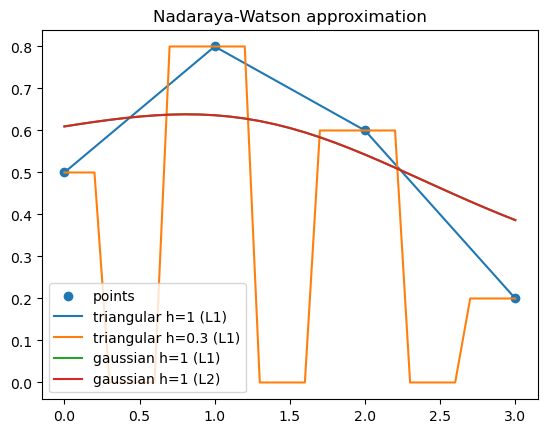

In [125]:
import numpy as np
import matplotlib.pyplot as plt

# исходные точки
x = np.array([0, 1, 2, 3])
y = np.array([0.5, 0.8, 0.6, 0.2])

x_est = np.arange(0, 3.1, 0.1)

# функция Надарая-Ватсона
def nw(x, y, x_est, h=1.0, kernel='triangular', metric='l1'):
    
    # расстояния
    if metric == 'l1':
        diff = np.abs(x_est[:, None] - x[None, :])
    elif metric == 'l2':
        diff = np.sqrt((x_est[:, None] - x[None, :])**2)
    
    r = diff / h

    # ядра
    if kernel == 'triangular':
        K = np.maximum(1 - r, 0)
    elif kernel == 'gaussian':
        K = (1 / np.sqrt(2*np.pi)) * np.exp(-r**2 / 2)

    # формула
    numerator = (K * y).sum(axis=1)
    denominator = K.sum(axis=1)

    # защита от деления на 0
    y_est = np.where(denominator != 0, numerator / denominator, 0)

    return y_est


# разные варианты
y_est_1 = nw(x, y, x_est, h=1.0, kernel='triangular', metric='l1')
y_est_2 = nw(x, y, x_est, h=0.3, kernel='triangular', metric='l1')
y_est_3 = nw(x, y, x_est, h=1.0, kernel='gaussian', metric='l1')
y_est_4 = nw(x, y, x_est, h=1.0, kernel='gaussian', metric='l2')


# график
plt.figure()

# исходные точки
plt.scatter(x, y, label='points')

# аппроксимации
plt.plot(x_est, y_est_1, label='triangular h=1 (L1)')
plt.plot(x_est, y_est_2, label='triangular h=0.3 (L1)')
plt.plot(x_est, y_est_3, label='gaussian h=1 (L1)')
plt.plot(x_est, y_est_4, label='gaussian h=1 (L2)')

plt.legend()
plt.title("Nadaraya-Watson approximation")
plt.show()

In [126]:
import numpy as np


def func(x):
    return 0.1 * x - np.cos(x/2) + 0.4 * np.sin(3*x) + 5


np.random.seed(0)

x = np.arange(-5.0, 5.0, 0.1) # значения по оси абсцисс [-5; 5] с шагом 0.1
y = func(x) + np.random.normal(0, 0.2, len(x)) # значения функции по оси ординат

# здесь продолжайте программу

In [136]:
h = 0.5
diff = np.abs(x[:, None] - x[None, :])
r = diff / h
K = np.sqrt(2 * np.pi) ** (-1) * np.exp(- r ** 2 / 2)
y_est = (K * y).sum(axis=1) / K.sum(axis=1)

In [134]:
K.shape

(100, 100)

In [135]:
y.shape

(100,)